# Seasonal Agriculture Performance Analysis

**Major Project: VOIS AICTE Batch 1 (2026–2027)**

Name- Mohit Sigchi\
AICTE ID- STU605da1eeefcd61616749038

This notebook analyzes the supplied agricultural dataset according to the project brief.

### Project focus
- Understand and clean the dataset
- Compare agricultural performance across **Kharif, Rabi and Zaid**
- Compare crops, states and irrigation methods
- Compare **resource usage directly across seasons**
- Examine environmental and economic relationships
- Test seasonal mean differences using a reproducible NumPy permutation procedure
- Identify **season-specific and overall unusual patterns/outliers**
- Produce evidence-based conclusions and recommendations

> **Library constraint:** This notebook uses Pandas, NumPy, Matplotlib and Seaborn. No SciPy statistical-test dependency is required.


## Questions Covered

The notebook addresses all twelve areas listed in the project brief:

1. How does agricultural performance vary across seasons?
2. What major seasonal patterns can be observed?
3. Which characteristics change between seasons?
4. What differences exist between agricultural activities in different seasons?
5. Are there noticeable variations in resource usage across seasons?
6. Are there relationships between seasonal environmental conditions and agricultural performance?
7. How do economic outcomes vary across seasons?
8. Are some seasonal patterns consistent across different regions or categories?
9. Are there unusual or unexpected seasonal patterns?
10. What insights can be derived from the observed seasonal differences?
11. What conclusions can reasonably be drawn from the available data?
12. How could the findings support better seasonal agricultural planning?


In [2]:
# Google Colab libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load the CSV



In [3]:
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 2. Understand the Dataset

In [4]:
print("Rows and columns:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)


Rows and columns: (4000, 28)

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data types:
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                 

In [5]:
print("Season distribution:")
print(df["Season"].value_counts())

print("\nDuplicate rows:", df.duplicated().sum())

if "Farm_ID" in df.columns:
    print("Duplicate Farm_IDs:", df["Farm_ID"].duplicated().sum())

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(10))


Season distribution:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Duplicate rows: 0
Duplicate Farm_IDs: 0

Missing values:
Rainfall_mm           48
Soil_Moisture_pct     40
Yield_Tonnes_Ha       32
Farm_ID                0
Crop                   0
District               0
Farm_Area_Hectares     0
Season                 0
Avg_Temperature_C      0
Humidity_pct           0
dtype: int64


## 3. Data Cleaning

The project brief asks us to clean and prepare the data. The cleaning steps are based on the actual dataset rather than assumptions:

- Check for duplicate rows and duplicate `Farm_ID` values.
- Inspect missing values.
- Median-impute the small number of missing values in `Rainfall_mm`, `Soil_Moisture_pct`, and `Yield_Tonnes_Ha`.
- Create `Profit_Margin_pct` for additional economic analysis.



In [6]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Farm_IDs:", df["Farm_ID"].duplicated().sum())

Duplicate rows: 0
Duplicate Farm_IDs: 0


Duplicate rows and Farm_IDs were checked. No duplicates were found, so no duplicate records were removed.

In [7]:
# Median imputation
for col in ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Derived metric
df["Profit_Margin_pct"] = np.where(
    df["Revenue_INR"] != 0,
    df["Profit_INR"] / df["Revenue_INR"] * 100,
    np.nan
)

print("Final shape:", df.shape)
print("Total remaining missing cells:", df.isna().sum().sum())


Final shape: (4000, 29)
Total remaining missing cells: 0


In [8]:
# Descriptive statistics
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,4000.0,NaN,NaN,NaN,600.922825,287.193381,80.0,371.575,582.0,831.975,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


## 4. Seasonal Performance

We compare both **mean and median** because the dataset contains large outliers, especially for yield and profit.


In [9]:
season_summary = df.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Median_Yield=("Yield_Tonnes_Ha", "median"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Cost=("Total_Cost_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Median_Profit=("Profit_INR", "median"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Disease_Pest_Risk=("Disease_Pest_Risk_pct", "mean"),
    Avg_Rainfall=("Rainfall_mm", "mean"),
    Avg_Temperature=("Avg_Temperature_C", "mean"),
    Avg_Humidity=("Humidity_pct", "mean"),
    Avg_Soil_Moisture=("Soil_Moisture_pct", "mean")
)

season_summary.round(2)

,Farms,Avg_Yield,Median_Yield,Avg_Revenue,Avg_Cost,Avg_Profit,Median_Profit,Avg_Water_Efficiency,Avg_Disease_Pest_Risk,Avg_Rainfall,Avg_Temperature,Avg_Humidity,Avg_Soil_Moisture
Season,,,,,,,,,,,,,
Kharif,1779,5.63,1.94,710719.06,531804.41,178914.65,38808.0,5.89,54.47,849.20,28.45,71.81,31.15
Rabi,1627,5.04,1.67,601526.05,513836.58,87689.47,-3187.0,5.19,40.48,437.62,23.49,57.89,24.07
Zaid,594,4.64,1.46,519171.90,543976.73,-24804.82,-62144.0,4.41,38.22,304.65,31.04,52.01,19.28


In [10]:
# Percentage of farms making a profit
profitability_by_season = (
    df.assign(Profitable=df["Profit_INR"] > 0)
      .groupby("Season")["Profitable"]
      .mean()
      .mul(100)
      .round(2)
      .rename("Profitability_Rate_pct")
)

profitability_by_season


,Profitability_Rate_pct
Season,
Kharif,57.79
Rabi,48.86
Zaid,35.52


### Interpretation

The dataset shows the following overall seasonal pattern:

- **Kharif** has the highest average yield, revenue, profit and water-use efficiency.
- **Rabi** generally performs in the middle.
- **Zaid** has the weakest average economic performance and a negative average profit.
- Kharif has the highest percentage of profitable farms.

These are associations in this dataset, not proof that season alone causes the differences.


## 5. Seasonal Visualizations

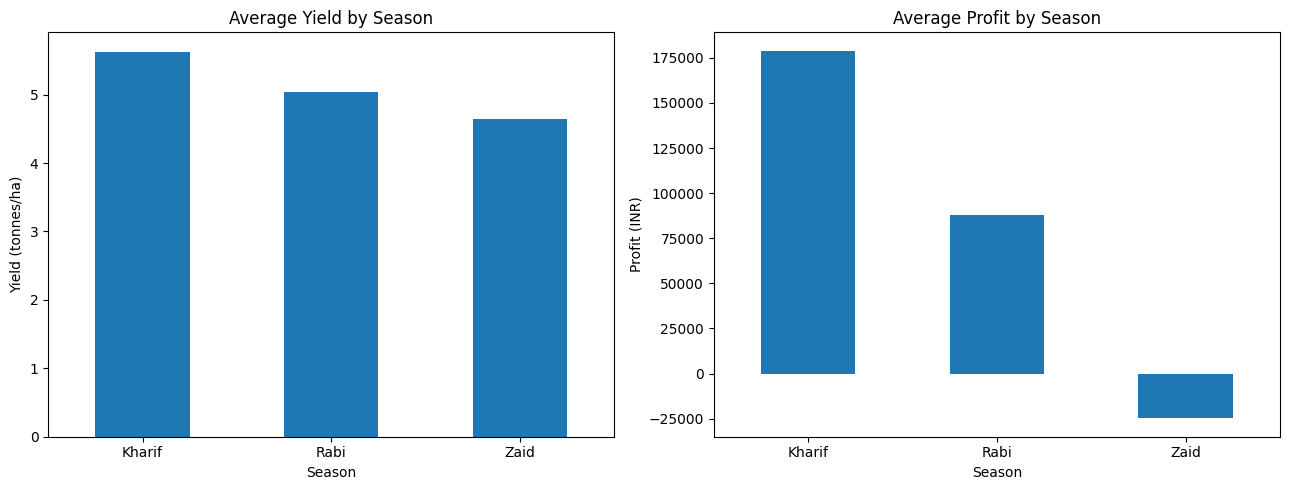

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

season_means = df.groupby("Season")[['Yield_Tonnes_Ha', 'Profit_INR']].mean()
season_means["Yield_Tonnes_Ha"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Yield by Season")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Yield (tonnes/ha)")
axes[0].tick_params(axis="x", rotation=0)

season_means["Profit_INR"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Profit by Season")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Profit (INR)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


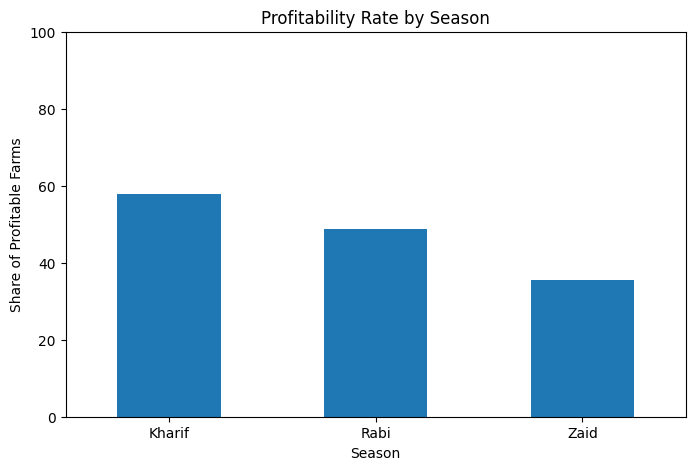

In [12]:
plt.figure(figsize=(8, 5))

profitability_by_season.plot(kind="bar")
plt.title("Profitability Rate by Season")
plt.xlabel("Season")
plt.ylabel("Share of Profitable Farms")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.show()


/tmp/ipykernel_4328/3171523763.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(season_profit_data, labels=sorted(df["Season"].dropna().unique()))


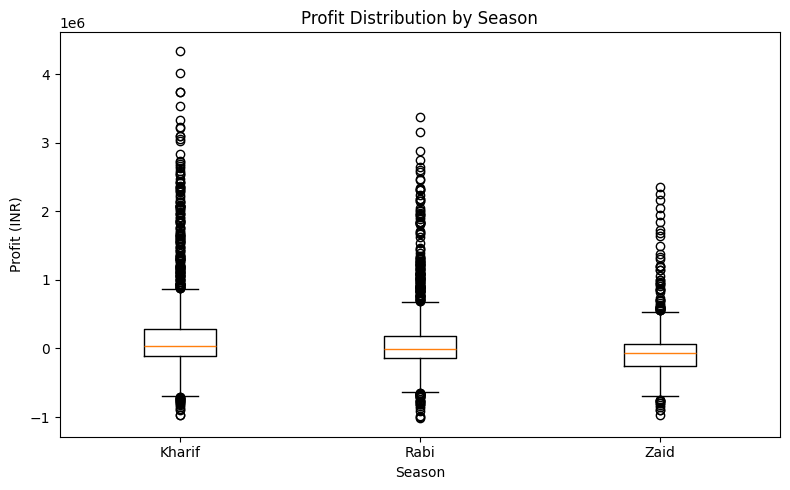

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

season_profit_data = [df.loc[df["Season"] == s, "Profit_INR"].dropna() for s in sorted(df["Season"].dropna().unique())]
ax.boxplot(season_profit_data, labels=sorted(df["Season"].dropna().unique()))
ax.set_title("Profit Distribution by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Profit (INR)")
plt.tight_layout()
plt.show()


## 6. Crop Analysis

In [14]:
crop_summary = df.groupby("Crop").agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Profitability_Rate=("Profit_INR", lambda s: (s > 0).mean() * 100)
).sort_values("Avg_Profit", ascending=False)

crop_summary.round(2)


,Avg_Yield,Avg_Profit,Profitability_Rate
Crop,,,
Sugarcane,46.64,817187.99,88.52
Chilli,1.54,750878.34,82.04
Cotton,1.23,124546.92,65.35
Groundnut,1.32,44858.12,59.20
Pulses,0.92,-4238.05,50.81
Maize,2.71,-83978.33,36.30
Rice,2.43,-102213.50,33.62
Wheat,2.11,-123398.34,25.90


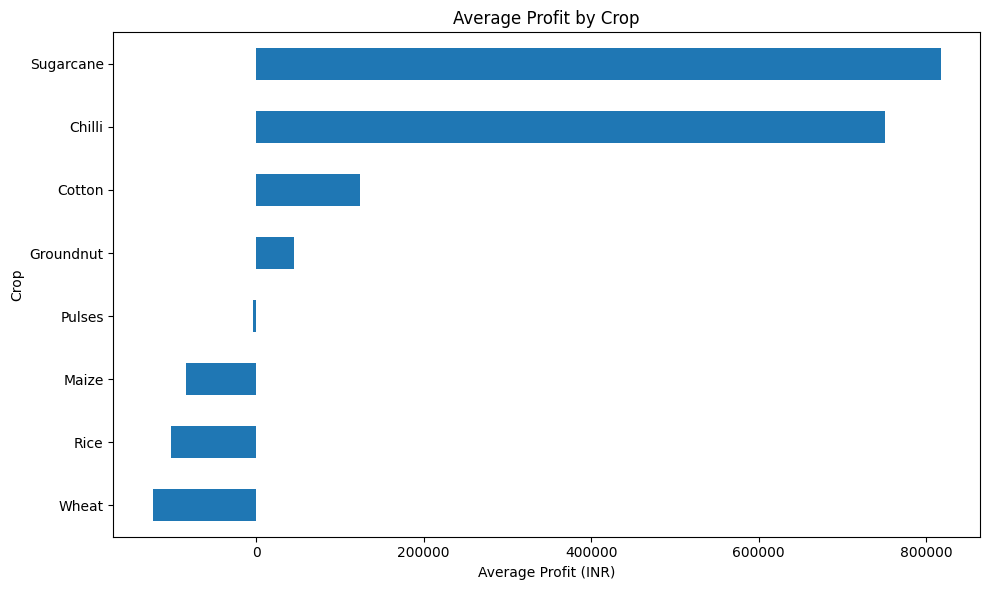

In [15]:
plt.figure(figsize=(10, 6))

plot_data = crop_summary.sort_values("Avg_Profit")
plot_data["Avg_Profit"].plot(kind="barh")
plt.title("Average Profit by Crop")
plt.xlabel("Average Profit (INR)")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()


In [16]:
crop_season_yield = df.pivot_table(
    index="Crop",
    columns="Season",
    values="Yield_Tonnes_Ha",
    aggfunc="mean"
)

crop_season_yield.round(2)


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


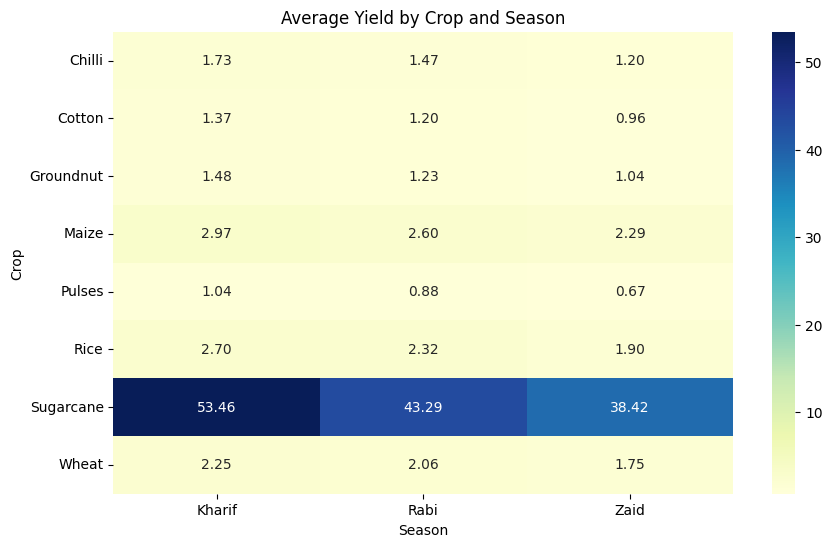

In [17]:
plt.figure(figsize=(10, 6))
sns.heatmap(crop_season_yield, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Yield by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.show()


## 7. Irrigation and Resource Usage

In [18]:
irrigation_summary = df.groupby("Irrigation_Method").agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Profitability_Rate=("Profit_INR", lambda s: (s > 0).mean() * 100),
    Avg_Water_Used=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).sort_values("Avg_Profit", ascending=False)

irrigation_summary.round(2)

,Avg_Yield,Avg_Profit,Profitability_Rate,Avg_Water_Used,Avg_Water_Efficiency
Irrigation_Method,,,,,
Drip,6.58,219626.00,59.78,5918.75,6.27
Sprinkler,5.16,91121.08,51.91,6208.26,4.67
Rainfed,4.60,79050.37,46.88,3549.55,7.56
Flood,4.86,73354.02,47.18,8026.47,3.44


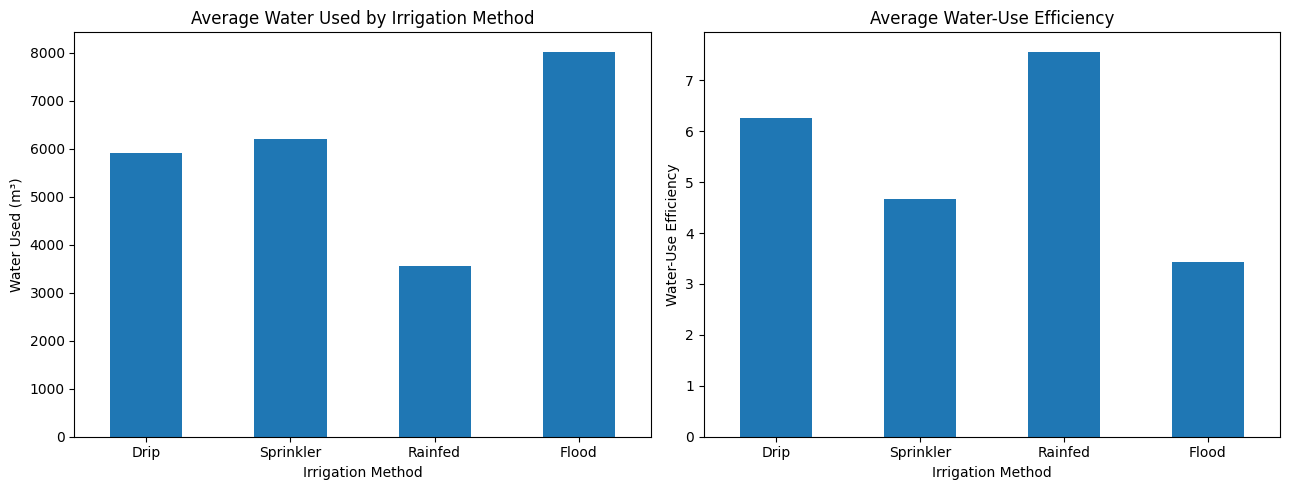

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

irrigation_plot = irrigation_summary.copy()
irrigation_plot["Avg_Water_Used"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Water Used by Irrigation Method")
axes[0].set_xlabel("Irrigation Method")
axes[0].set_ylabel("Water Used (m³)")
axes[0].tick_params(axis="x", rotation=0)

irrigation_plot["Avg_Water_Efficiency"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Water-Use Efficiency")
axes[1].set_xlabel("Irrigation Method")
axes[1].set_ylabel("Water-Use Efficiency")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


### 7.1 Resource Usage Across Seasons

The project brief specifically asks whether resource usage varies across seasons. Therefore, we compare resource-related variables directly across **Kharif, Rabi and Zaid**, in addition to the irrigation-method comparison above.

The selected measures are:

- Water used (`m³`)
- Fertilizer used (`kg/ha`)
- Pesticide used (`litres/ha`)
- Water-use efficiency (`tonnes per 1,000 m³`)


In [20]:
season_resource_summary = df.groupby("Season").agg(
    Avg_Water_Used_m3=("Water_Used_m3", "mean"),
    Avg_Fertilizer_kg_ha=("Fertilizer_kg_ha", "mean"),
    Avg_Pesticide_Litre_ha=("Pesticide_Litre_ha", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).round(2)

season_resource_summary


,Avg_Water_Used_m3,Avg_Fertilizer_kg_ha,Avg_Pesticide_Litre_ha,Avg_Water_Efficiency
Season,,,,
Kharif,6102.20,187.08,5.08,5.89
Rabi,5846.99,185.41,5.02,5.19
Zaid,6419.89,184.64,5.17,4.41


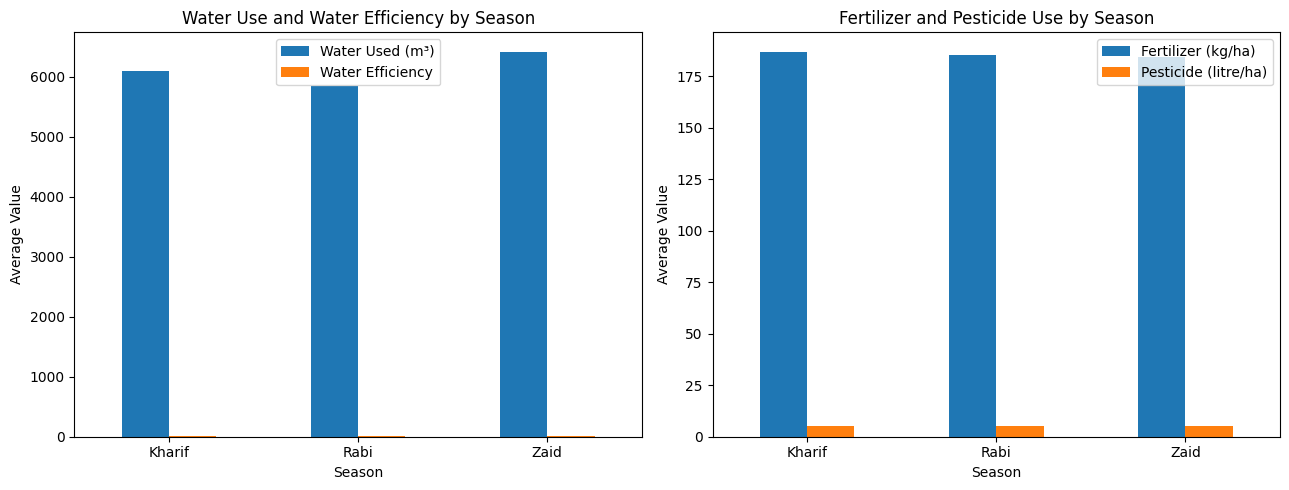

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

season_resource_summary[["Avg_Water_Used_m3", "Avg_Water_Efficiency"]].plot(
    kind="bar", ax=axes[0]
)
axes[0].set_title("Water Use and Water Efficiency by Season")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Average Value")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(["Water Used (m³)", "Water Efficiency"])

season_resource_summary[["Avg_Fertilizer_kg_ha", "Avg_Pesticide_Litre_ha"]].plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("Fertilizer and Pesticide Use by Season")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Average Value")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(["Fertilizer (kg/ha)", "Pesticide (litre/ha)"])

plt.tight_layout()
plt.show()


### Resource-use interpretation

The seasonal comparison shows that water use and water-use efficiency vary across seasons, while average fertilizer and pesticide usage are comparatively close.


## 8. Environmental Conditions by Season

In [22]:
environmental_summary = df.groupby("Season").agg(
    Rainfall_mm=("Rainfall_mm", "mean"),
    Temperature_C=("Avg_Temperature_C", "mean"),
    Humidity_pct=("Humidity_pct", "mean"),
    Soil_Moisture_pct=("Soil_Moisture_pct", "mean"),
    Sunlight_Hours=("Sunlight_Hours_Day", "mean")
).round(2)

environmental_summary

,Rainfall_mm,Temperature_C,Humidity_pct,Soil_Moisture_pct,Sunlight_Hours
Season,,,,,
Kharif,849.20,28.45,71.81,31.15,6.79
Rabi,437.62,23.49,57.89,24.07,7.59
Zaid,304.65,31.04,52.01,19.28,8.18


The table above shows the average environmental conditions for each season: Kharif, Rabi, and Zaid. It includes the mean rainfall, temperature, humidity, soil moisture, and sunlight hours per day, all rounded to two decimal places. This summary highlights how these conditions vary across the different agricultural seasons.

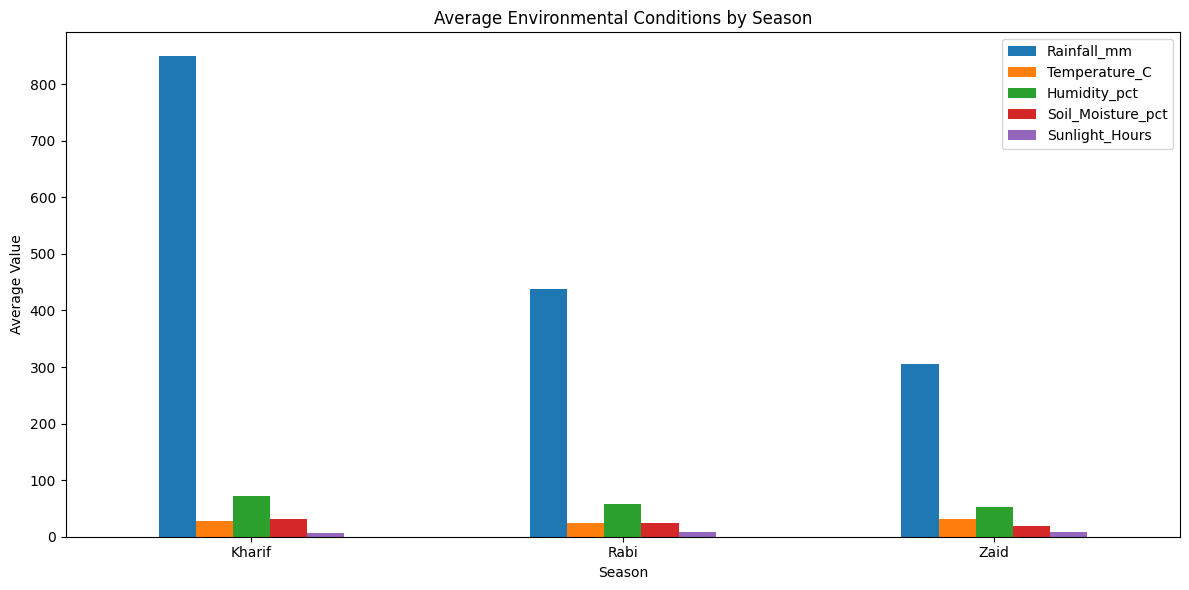

In [23]:
environmental_summary.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Environmental Conditions by Season")
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 9. Correlation Analysis

This notebook uses **Pandas `.corr()`**, which calculates **Pearson correlation** by default.

Interpretation:

- Near **+1** → strong positive linear relationship
- Near **-1** → strong negative linear relationship
- Near **0** → weak/no linear relationship

Correlation does **not** prove causation.


In [24]:
corr_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Soil_Moisture_pct",
    "Water_Used_m3",
    "Yield_Tonnes_Ha",
    "Profit_INR"
]

correlation = df[corr_cols].corr()
correlation.round(3)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Water_Used_m3,Yield_Tonnes_Ha,Profit_INR
Rainfall_mm,1.000,0.198,0.521,0.509,0.002,0.031,0.108
Avg_Temperature_C,0.198,1.000,0.138,0.084,0.023,0.010,0.009
Humidity_pct,0.521,0.138,1.000,0.446,-0.002,0.012,0.064
Soil_Moisture_pct,0.509,0.084,0.446,1.000,0.003,0.011,0.091
Water_Used_m3,0.002,0.023,-0.002,0.003,1.000,0.386,0.190
Yield_Tonnes_Ha,0.031,0.010,0.012,0.011,0.386,1.000,0.488
Profit_INR,0.108,0.009,0.064,0.091,0.190,0.488,1.000


This matrix shows the Pearson correlation coefficient between each pair of the selected variables. Values close to 1 indicate a strong positive linear relationship, values close to -1 indicate a strong negative linear relationship, and values close to 0 indicate a weak or no linear relationship. For instance, Yield_Tonnes_Ha has a correlation of 0.39 with Water_Used_m3 and 0.49 with Profit_INR, suggesting moderate positive relationships.

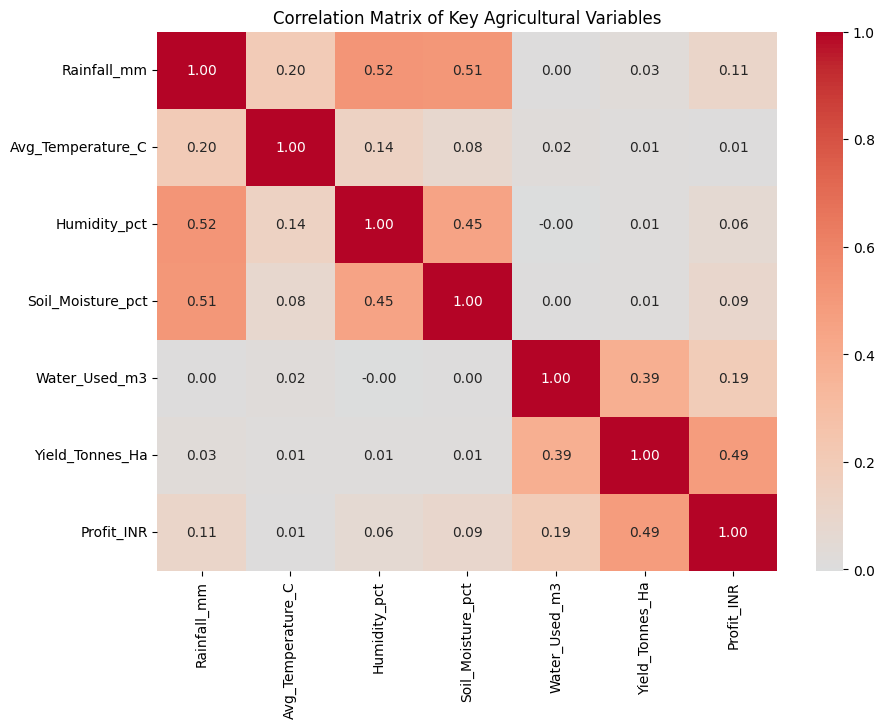

In [25]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix of Key Agricultural Variables")
plt.show()


In [26]:
# Variables most strongly correlated with yield
yield_correlations = (
    correlation["Yield_Tonnes_Ha"]
    .drop("Yield_Tonnes_Ha")
    .sort_values(key=abs, ascending=False)
    .round(3)
)

yield_correlations


,Yield_Tonnes_Ha
Profit_INR,0.488
Water_Used_m3,0.386
Rainfall_mm,0.031
Humidity_pct,0.012
Soil_Moisture_pct,0.011
Avg_Temperature_C,0.010


### Correlation by Season

A single overall correlation can hide seasonal differences. We therefore calculate Pearson correlations separately for each season.


In [27]:
season_yield_corr = {}

for season in sorted(df["Season"].dropna().unique()):
    season_data = df.loc[df["Season"] == season, corr_cols]
    season_yield_corr[season] = (
        season_data.corr()["Yield_Tonnes_Ha"]
        .drop("Yield_Tonnes_Ha")
    )

season_yield_corr_df = pd.DataFrame(season_yield_corr).round(3)
season_yield_corr_df


,Kharif,Rabi,Zaid
Rainfall_mm,-0.015,0.044,0.052
Avg_Temperature_C,-0.011,0.055,-0.044
Humidity_pct,-0.016,0.019,-0.061
Soil_Moisture_pct,0.001,-0.017,-0.031
Water_Used_m3,0.357,0.423,0.405
Profit_INR,0.467,0.515,0.527


## 10. Seasonal Difference Significance — NumPy Permutation Test

The project asks us to identify significant differences or unusual patterns. To strengthen that part of the analysis, this notebook uses a **permutation test implemented with NumPy**.

For each pair of seasons, the test repeatedly shuffles the combined observations and checks how often a difference in means as large as the observed difference occurs by chance.

- Number of permutations: 5,000
- Random seed: 42 for reproducibility
- Two-sided absolute difference in means
- Bonferroni-adjusted p-values for the three pairwise season comparisons
- Significance level: 0.05

This keeps the notebook free of external statistical-test dependencies while still providing an inferential check.


In [28]:
from itertools import combinations

def permutation_p_value(group_a, group_b, n_permutations=5000, seed=42):
    """Two-sided permutation p-value for a difference in means."""
    rng = np.random.default_rng(seed)
    group_a = np.asarray(group_a, dtype=float)
    group_b = np.asarray(group_b, dtype=float)

    observed = abs(group_a.mean() - group_b.mean())
    pooled = np.concatenate([group_a, group_b])
    n_a = len(group_a)
    count = 0

    for _ in range(n_permutations):
        shuffled = rng.permutation(pooled)
        permuted_diff = abs(shuffled[:n_a].mean() - shuffled[n_a:].mean())
        if permuted_diff >= observed:
            count += 1

    return (count + 1) / (n_permutations + 1)


def seasonal_permutation_analysis(column, n_permutations=5000):
    rows = []
    seasons = sorted(df["Season"].dropna().unique())
    pairs = list(combinations(seasons, 2))

    for season_a, season_b in pairs:
        a = df.loc[df["Season"] == season_a, column].dropna().to_numpy()
        b = df.loc[df["Season"] == season_b, column].dropna().to_numpy()
        mean_difference = a.mean() - b.mean()
        p_value = permutation_p_value(a, b, n_permutations=n_permutations, seed=42)
        rows.append({
            "Variable": column,
            "Season_A": season_a,
            "Season_B": season_b,
            "Mean_A": a.mean(),
            "Mean_B": b.mean(),
            "Mean_Difference_A_minus_B": mean_difference,
            "Raw_p_value": p_value
        })

    result = pd.DataFrame(rows)
    result["Bonferroni_Adjusted_p"] = np.minimum(result["Raw_p_value"] * len(pairs), 1.0)
    result["Significant_at_0.05"] = result["Bonferroni_Adjusted_p"] < 0.05
    return result

# Analyze multiple variables using a loop
variables_to_analyze = ["Yield_Tonnes_Ha", "Profit_INR"]
all_significance_results = [seasonal_permutation_analysis(var) for var in variables_to_analyze]

significance_results = pd.concat(all_significance_results, ignore_index=True).round(4)


In [29]:
print("Statistical interpretation")
print("-" * 60)

for variable, label in [("Yield_Tonnes_Ha", "yield"), ("Profit_INR", "profit")]:
    temp = significance_results[significance_results["Variable"] == variable]
    significant_pairs = temp.loc[temp["Significant_at_0.05"], ["Season_A", "Season_B"]]

    if len(significant_pairs) == 0:
        print(f"No pairwise seasonal difference in {label} was significant after adjustment at the 0.05 level.")
    else:
        pairs_text = ", ".join(
            f"{row.Season_A} vs {row.Season_B}"
            for row in significant_pairs.itertuples()
        )
        print(f"Significant pairwise seasonal differences in {label}: {pairs_text}.")

print("Note: Statistical significance indicates evidence of a difference in the sample under this permutation procedure; it does not establish causation.")


Statistical interpretation
------------------------------------------------------------
No pairwise seasonal difference in yield was significant after adjustment at the 0.05 level.
Significant pairwise seasonal differences in profit: Kharif vs Rabi, Kharif vs Zaid, Rabi vs Zaid.
Note: Statistical significance indicates evidence of a difference in the sample under this permutation procedure; it does not establish causation.


### Statistical interpretation

The descriptive tables show how the seasons differ, while the permutation test checks whether the observed mean differences are unusually large relative to random reassignments of the season labels.


## 11. Regional Consistency


In [30]:
state_season_profit = df.pivot_table(
    index="State",
    columns="Season",
    values="Profit_INR",
    aggfunc="mean"
).round(2)

state_season_profit


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169315.52,26315.71,-84084.87
Gujarat,217051.33,82846.20,-106929.61
Karnataka,201226.21,70952.61,23310.91
Madhya Pradesh,134242.40,61576.26,209.70
Maharashtra,168801.05,159581.50,-40597.60
Punjab,133779.10,169294.52,62109.69
Tamil Nadu,211303.96,70456.86,-15175.20
Telangana,199668.38,62824.60,-34620.78


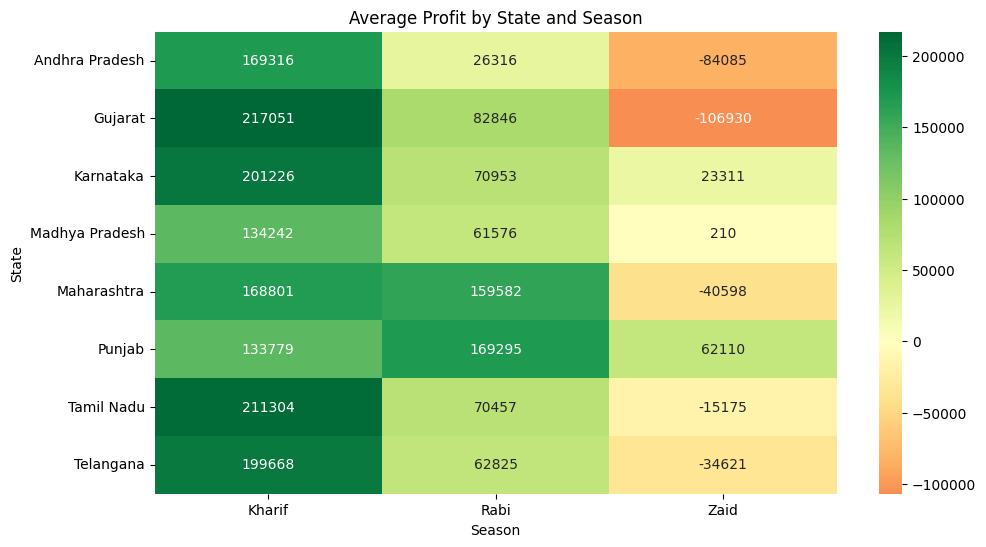

In [31]:
plt.figure(figsize=(11, 6))
sns.heatmap(
    state_season_profit,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    center=0
)
plt.title("Average Profit by State and Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.show()


In [32]:
best_season_by_state = state_season_profit.idxmax(axis=1)

print("Best season by average profit in each state:")
print(best_season_by_state)

print("\nNumber of states for which each season is best:")
print(best_season_by_state.value_counts())


Best season by average profit in each state:
State
Andhra Pradesh    Kharif
Gujarat           Kharif
Karnataka         Kharif
Madhya Pradesh    Kharif
Maharashtra       Kharif
Punjab              Rabi
Tamil Nadu        Kharif
Telangana         Kharif
dtype: object

Number of states for which each season is best:
Kharif    7
Rabi      1
Name: count, dtype: int64


## 12. Seasonal Unusual-Pattern Analysis

Overall outliers are useful, but the project also asks whether there are **unusual seasonal patterns**. We therefore calculate IQR-based outlier counts separately for each season and inspect season-specific distributions.


In [33]:
def seasonal_iqr_outlier_counts(data, columns):
    rows = []
    for season, group in data.groupby("Season"):
        for col in columns:
            q1 = group[col].quantile(0.25)
            q3 = group[col].quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            count = ((group[col] < lower) | (group[col] > upper)).sum()
            rows.append({
                "Season": season,
                "Variable": col,
                "Outlier_Count": int(count),
                "Minimum": group[col].min(),
                "Median": group[col].median(),
                "Maximum": group[col].max()
            })
    return pd.DataFrame(rows)

seasonal_unusual_patterns = seasonal_iqr_outlier_counts(
    df,
    ["Yield_Tonnes_Ha", "Profit_INR"]
)

seasonal_unusual_patterns.round(2)


,Season,Variable,Outlier_Count,Minimum,Median,Maximum
0,Kharif,Yield_Tonnes_Ha,121,0.3,1.94,101.44
1,Kharif,Profit_INR,184,-976860.0,38808.00,4345421.00
2,Rabi,Yield_Tonnes_Ha,125,0.3,1.67,93.13
3,Rabi,Profit_INR,174,-1019223.0,-3187.00,3378879.00
4,Zaid,Yield_Tonnes_Ha,50,0.3,1.46,64.76
5,Zaid,Profit_INR,64,-965197.0,-62144.00,2349990.00


/tmp/ipykernel_4328/780532806.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(yield_data, labels=seasons)
/tmp/ipykernel_4328/780532806.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(profit_data, labels=seasons)


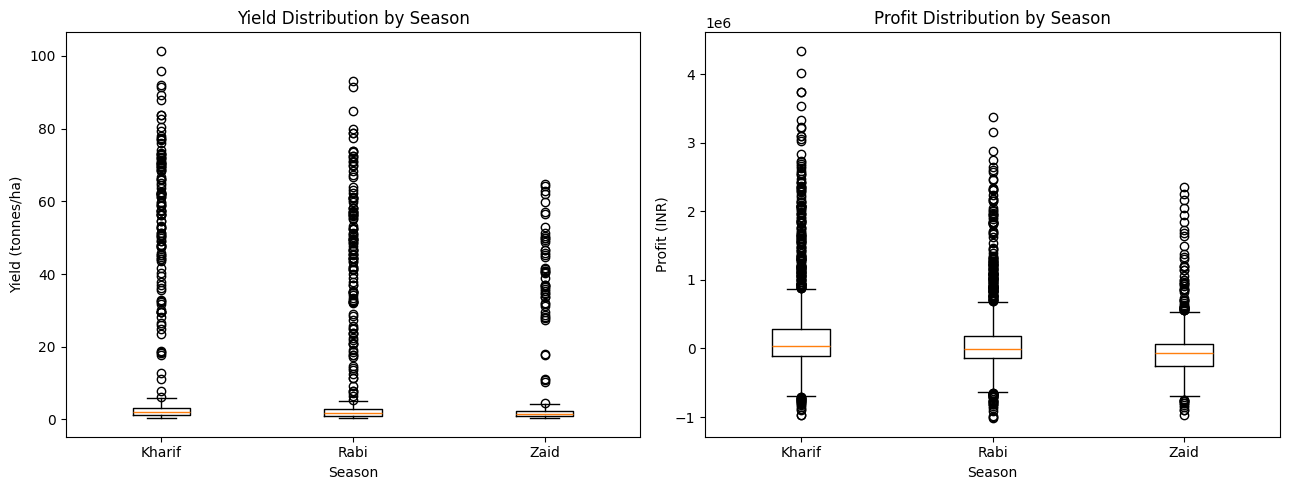

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

seasons = sorted(df["Season"].dropna().unique())
yield_data = [df.loc[df["Season"] == s, "Yield_Tonnes_Ha"].dropna() for s in seasons]
profit_data = [df.loc[df["Season"] == s, "Profit_INR"].dropna() for s in seasons]

axes[0].boxplot(yield_data, labels=seasons)
axes[0].set_title("Yield Distribution by Season")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Yield (tonnes/ha)")

axes[1].boxplot(profit_data, labels=seasons)
axes[1].set_title("Profit Distribution by Season")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Profit (INR)")

plt.tight_layout()
plt.show()


### Unusual-pattern interpretation

These season-specific tables and boxplots distinguish ordinary seasonal variation from extreme observations. Large outliers should be investigated rather than automatically deleted because they may represent genuine high-output or high-loss farms.


## 13. Overall Outlier Analysis

The IQR rule identifies potential outliers.

`IQR = Q3 - Q1`

Potential outliers are values below `Q1 - 1.5 × IQR` or above `Q3 + 1.5 × IQR`.


In [35]:
def iqr_outlier_summary(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((series < lower) | (series > upper)).sum()

    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": int(count)
    }

outlier_table = pd.DataFrame({
    col: iqr_outlier_summary(df[col])
    for col in ["Yield_Tonnes_Ha", "Profit_INR", "Water_Efficiency_t_per_1000m3"]
}).T

outlier_table.round(2)

,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
Yield_Tonnes_Ha,1.05,2.83,1.78,-1.62,5.50,302.0
Profit_INR,-148731.75,216187.75,364919.50,-696111.00,763567.00,404.0
Water_Efficiency_t_per_1000m3,1.66,5.15,3.49,-3.57,10.38,322.0


In [36]:
top_5_crops_by_profit = crop_summary.nlargest(5, 'Avg_Profit')
display(top_5_crops_by_profit[['Avg_Profit']])

,Avg_Profit
Crop,
Sugarcane,817187.986885
Chilli,750878.342233
Cotton,124546.915354
Groundnut,44858.120283
Pulses,-4238.052419


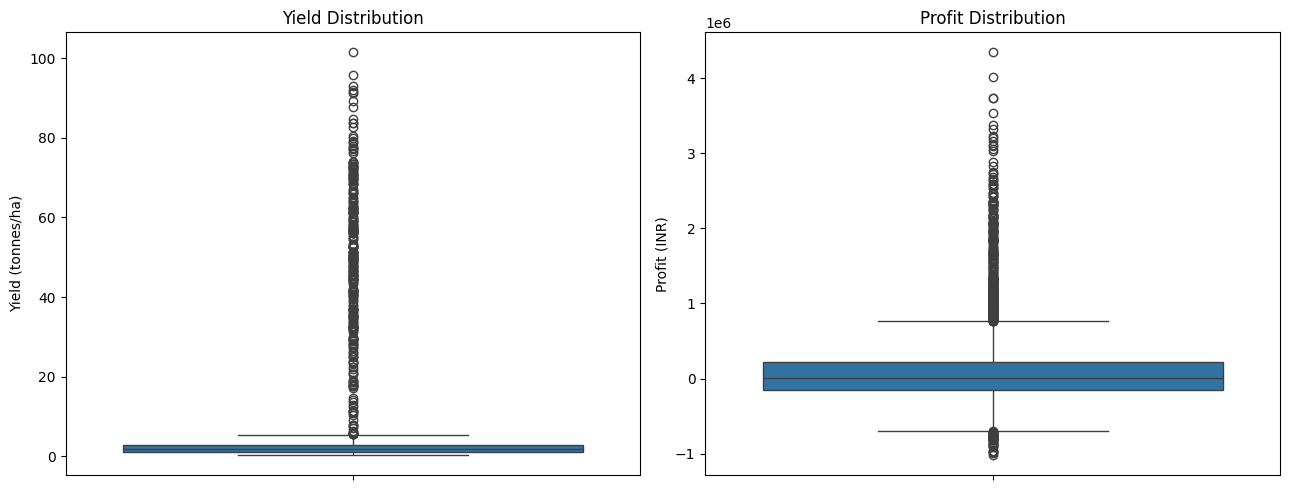

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(y=df["Yield_Tonnes_Ha"], ax=axes[0])
axes[0].set_title("Yield Distribution")
axes[0].set_ylabel("Yield (tonnes/ha)")

sns.boxplot(y=df["Profit_INR"], ax=axes[1])
axes[1].set_title("Profit Distribution")
axes[1].set_ylabel("Profit (INR)")

plt.tight_layout()
plt.show()


## 14. Key Results for the Report

The following code automatically prints the main project findings.


In [38]:
best_profit_season = season_summary["Avg_Profit"].idxmax()
worst_profit_season = season_summary["Avg_Profit"].idxmin()
best_yield_season = season_summary["Avg_Yield"].idxmax()
best_crop = crop_summary["Avg_Profit"].idxmax()
worst_crop = crop_summary["Avg_Profit"].idxmin()
best_irrigation = irrigation_summary["Avg_Profit"].idxmax()

print("KEY FINDINGS")
print("=" * 70)

print(
    f"1. Highest average yield season: {best_yield_season} "
    f"({season_summary.loc[best_yield_season, 'Avg_Yield']:.2f} tonnes/ha)"
)

print(
    f"2. Highest average profit season: {best_profit_season} "
    f"(₹{season_summary.loc[best_profit_season, 'Avg_Profit']:,.2f})"
)

print(
    f"3. Lowest average profit season: {worst_profit_season} "
    f"(₹{season_summary.loc[worst_profit_season, 'Avg_Profit']:,.2f})"
)

print(
    f"4. Highest profitability rate: {profitability_by_season.idxmax()} "
    f"({profitability_by_season.max():.2f}%)"
)

print(
    f"5. Highest-profit crop: {best_crop} "
    f"(₹{crop_summary.loc[best_crop, 'Avg_Profit']:,.2f})"
)

print(
    f"6. Lowest-profit crop: {worst_crop} "
    f"(₹{crop_summary.loc[worst_crop, 'Avg_Profit']:,.2f})"
)

print(
    f"7. Highest-profit irrigation method: {best_irrigation} "
    f"(₹{irrigation_summary.loc[best_irrigation, 'Avg_Profit']:,.2f})"
)


KEY FINDINGS
1. Highest average yield season: Kharif (5.63 tonnes/ha)
2. Highest average profit season: Kharif (₹178,914.65)
3. Lowest average profit season: Zaid (₹-24,804.82)
4. Highest profitability rate: Kharif (57.79%)
5. Highest-profit crop: Sugarcane (₹817,187.99)
6. Lowest-profit crop: Wheat (₹-123,398.34)
7. Highest-profit irrigation method: Drip (₹219,626.00)


## 16. Final Conclusions

### 1. Seasonal performance
Kharif is the strongest overall season in the dataset, Rabi is intermediate, and Zaid is the weakest economically.

### 2. Environmental pattern
Kharif has higher rainfall, humidity and soil moisture, while Zaid is hotter and drier.

### 3. Resource usage
Resource use varies across seasons. Water use and water-use efficiency show clearer seasonal differences than average fertilizer and pesticide usage.

### 4. Crop performance
Crop choice has a major effect on economic performance. Some crops are considerably more profitable than others, and crop-level performance can differ by season.

### 5. Irrigation
Drip irrigation shows strong yield and profit performance, while Flood irrigation uses more water and has lower water-use efficiency in this dataset.

### 6. Relationships
Individual environmental variables generally do not explain agricultural performance by themselves. The outcome is multifactorial.

### 7. Statistical significance
The permutation analysis provides an additional check of seasonal mean differences without external statistical-test libraries. The results should be interpreted as statistical evidence within this sample, not as proof of causation.

### 8. Unusual observations
Yield and profit distributions contain substantial outliers. These should be investigated rather than automatically removed because extreme observations may represent genuine farm outcomes.

## Recommendations

1. Prioritize strong crop–season combinations where local conditions support them.
2. Investigate Zaid-season combinations with low or negative profitability.
3. Compare resource use by season when planning irrigation and input requirements.
4. Consider efficient irrigation methods such as Drip where technically and economically appropriate.
5. Use mean, median and distribution plots when reporting highly skewed agricultural variables.
6. Consider crop, region, irrigation, environmental and economic factors together rather than using season alone.
7. Interpret correlation and statistical significance as evidence about the observed sample, not as causal proof.

### Project takeaway

**Kharif shows the strongest overall agricultural and economic performance in this dataset, while Zaid requires the most attention. Better seasonal planning should combine season, crop, irrigation, environmental, resource and economic information.**
